# Model evaluation: paper figures
Loads pre-computed arrays from `01_generate_eval_data.ipynb` and produces `Figure_S_plot_level_eval.pdf` and `Figure_S_grid_level_eval.pdf`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from western_us_biomass import dir_info

DATA_DIR = "../figure_data/figure_S_Evaluation/"

In [2]:
from western_us_biomass.make_figures import figure_settings

In [3]:
figure_settings.apply_style()

## Load data

In [4]:
y_test_init_ensemble = np.load(DATA_DIR + "y_test_init.npy")
y_test_burned_ensemble = np.load(DATA_DIR + "y_test_burned.npy")
y_test_undisturbed_ensemble = np.load(DATA_DIR + "y_test_undisturbed.npy")
y_pred_init_test_ensemble = np.load(DATA_DIR + "y_pred_init_test.npy")
y_pred_burned_test_ensemble = np.load(DATA_DIR + "y_pred_burned_test.npy")
y_pred_undisturbed_test_ensemble = np.load(DATA_DIR + "y_pred_undisturbed_test.npy")

ds_binned_obs_init = xr.open_dataset(DATA_DIR + "ds_binned_obs_init.nc")
ds_binned_modeled_init = xr.open_dataset(DATA_DIR + "ds_binned_modeled_init.nc")
ds_binned_obs_burned = xr.open_dataset(DATA_DIR + "ds_binned_obs_burned.nc")
ds_binned_modeled_burned = xr.open_dataset(DATA_DIR + "ds_binned_modeled_burned.nc")
ds_binned_obs_undisturbed = xr.open_dataset(DATA_DIR + "ds_binned_obs_undisturbed.nc")
ds_binned_modeled_undisturbed = xr.open_dataset(DATA_DIR + "ds_binned_modeled_undisturbed.nc")

In [5]:
plotid_init = np.load(DATA_DIR + "plotid_init.npy", allow_pickle=True)
plotid_burned = np.load(DATA_DIR + "plotid_burned.npy", allow_pickle=True)
plotid_undisturbed = np.load(DATA_DIR + "plotid_undisturbed.npy", allow_pickle=True)

In [6]:
import pandas as pd

y_test_init = pd.Series(y_test_init_ensemble).groupby(plotid_init).mean().values
y_test_burned = pd.Series(y_test_burned_ensemble).groupby(plotid_burned).mean().values
y_test_undisturbed = (
    pd.Series(y_test_undisturbed_ensemble).groupby(plotid_undisturbed).mean().values
)
y_pred_init_test = pd.Series(y_pred_init_test_ensemble).groupby(plotid_init).mean().values
y_pred_burned_test = pd.Series(y_pred_burned_test_ensemble).groupby(plotid_burned).mean().values
y_pred_undisturbed_test = (
    pd.Series(y_pred_undisturbed_test_ensemble).groupby(plotid_undisturbed).mean().values
)

## Figure S: plot-level evaluation

In [7]:
def annotate_stats(ax, y_true, y_pred):
    lr = LinearRegression().fit(y_true.reshape(-1, 1), y_pred)
    beta_0 = lr.intercept_
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    txt = f"$R^2$ = {r2:.2f}\n$\\beta_0$ = {beta_0:.2f}\nRMSE = {rmse:.2f}"
    ax.text(
        0.02,
        0.98,
        txt,
        transform=ax.transAxes,
        fontsize=figure_settings.style_settings["legend.fontsize"],
        va="top",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )
    return lr

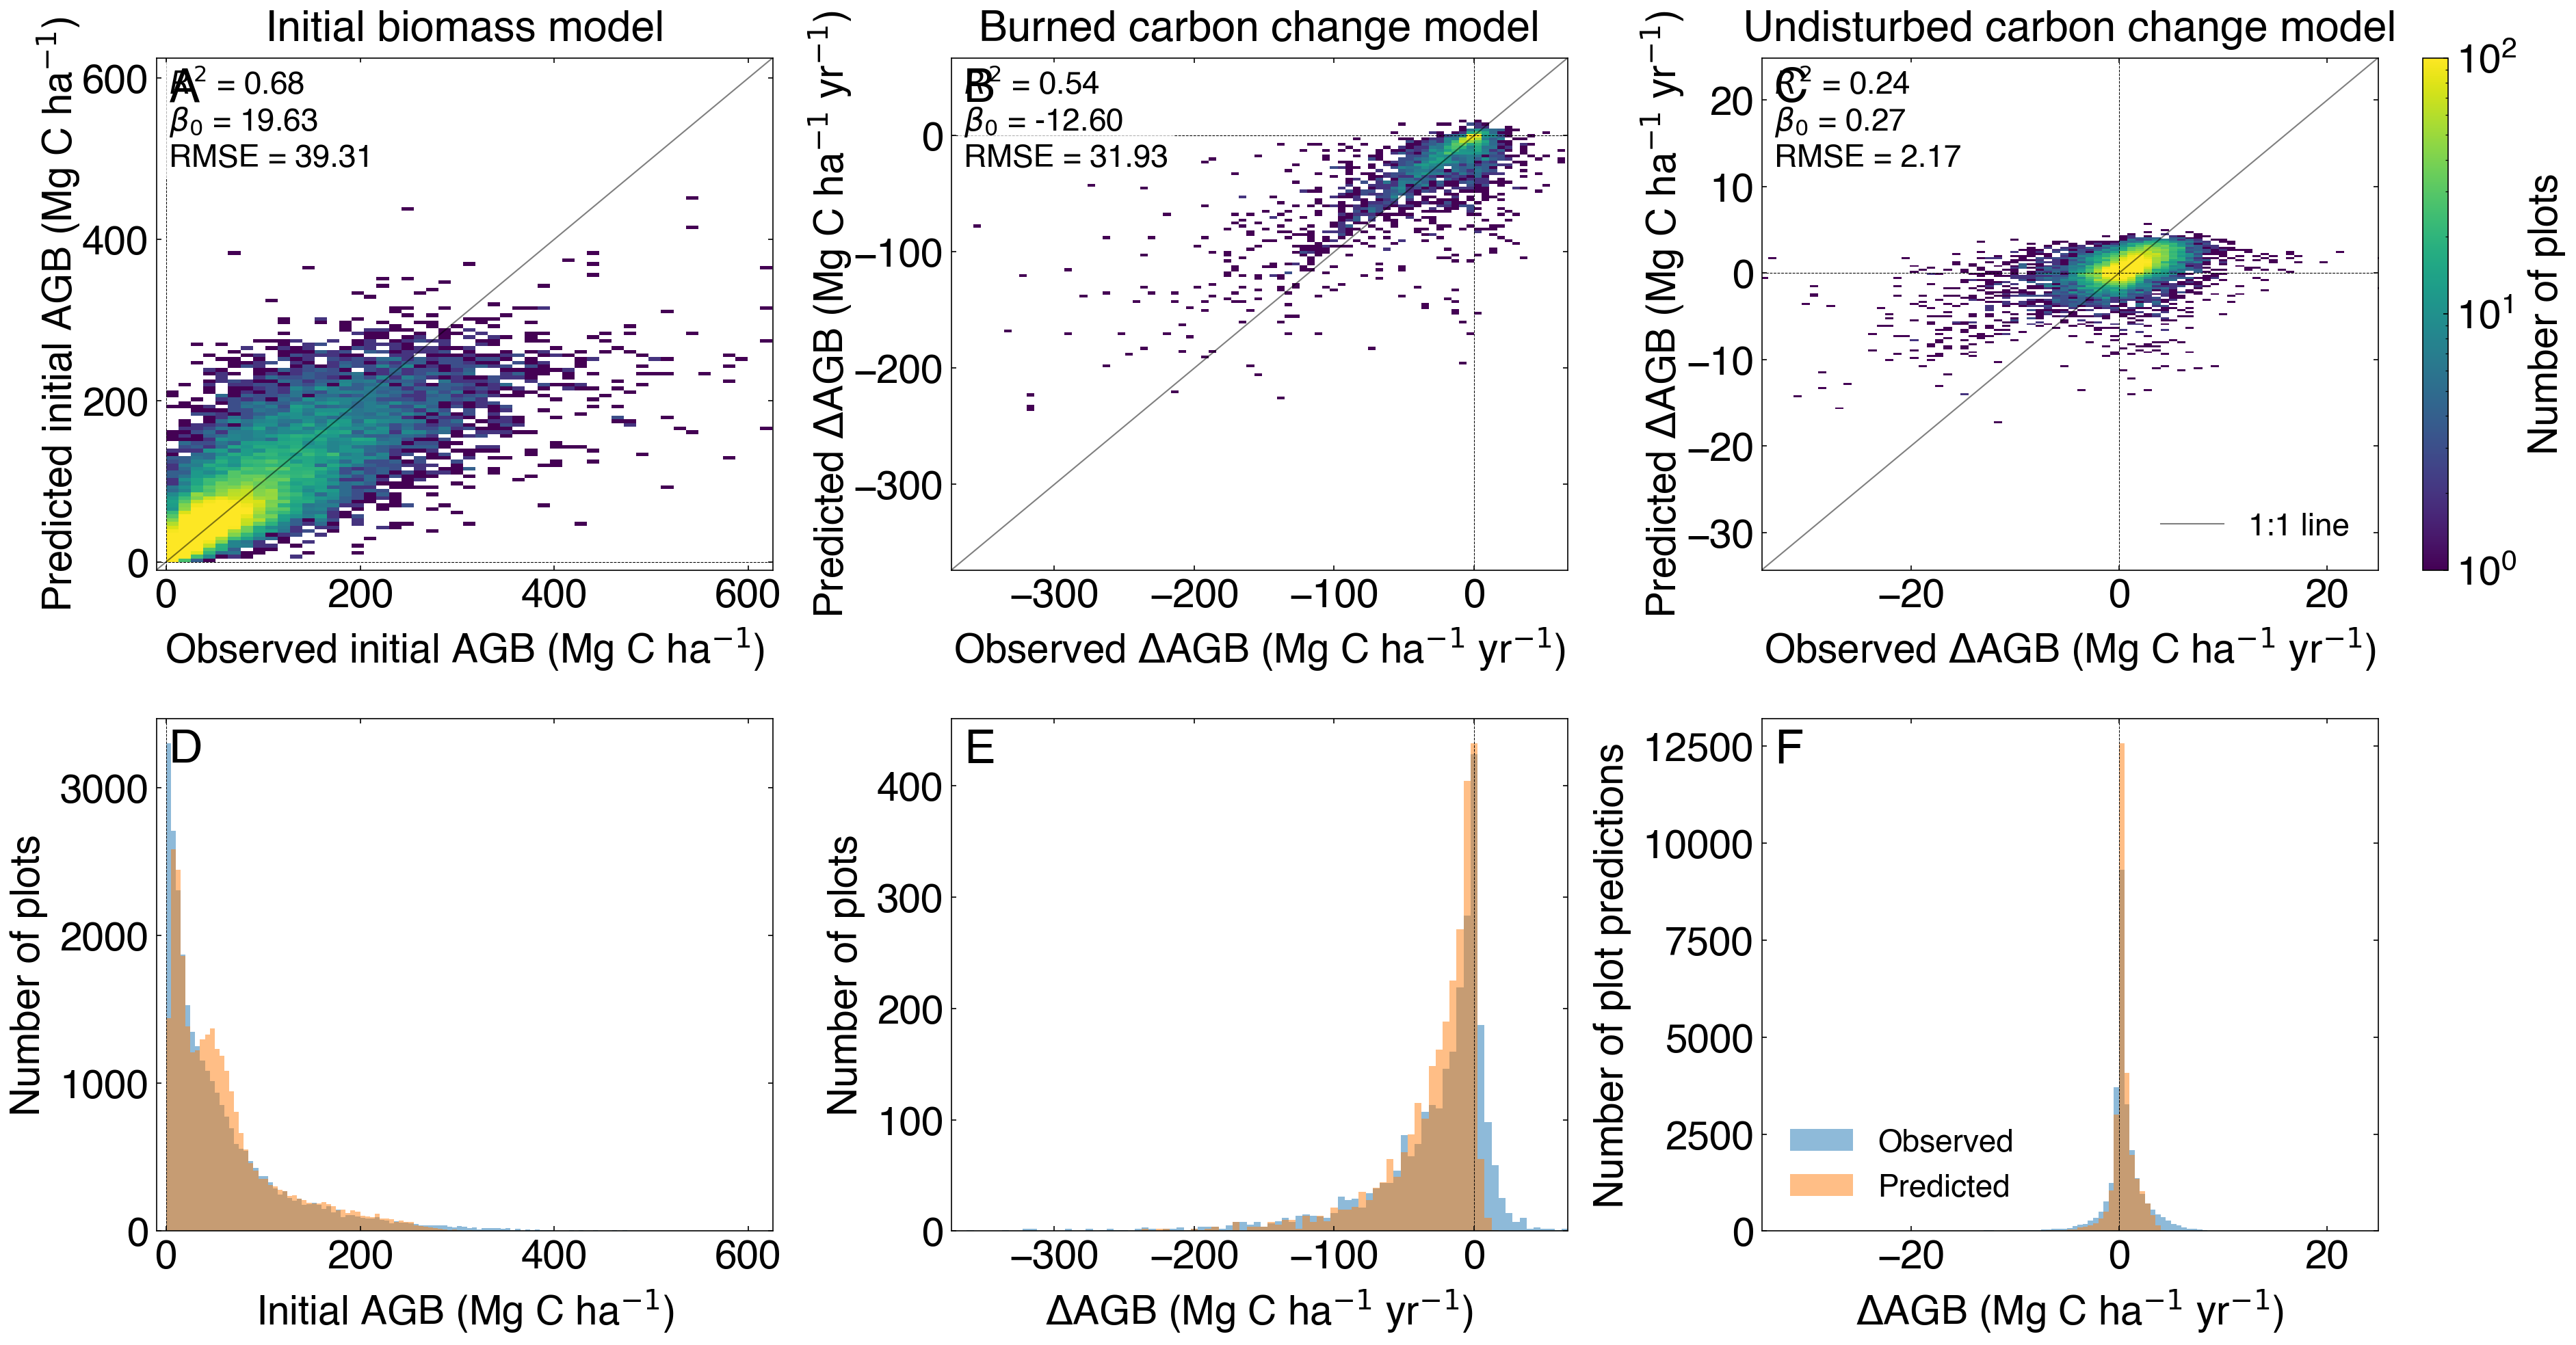

In [8]:
plt.rcParams.update({"font.size": 14})

fig, axes = plt.subplots(
    2,
    3,
    figsize=(25, 13),
    constrained_layout=True,
    gridspec_kw={"hspace": 0.07, "wspace": 0.03},
)
norm = plt.cm.colors.LogNorm(vmax=100)
cmap = "viridis"

xmin_init, xmax_init = -10, np.percentile(np.concatenate([y_test_init, y_pred_init_test]), 99.995)
xmin_burned, xmax_burned = (
    np.percentile(np.concatenate([y_test_burned, y_pred_burned_test]), 0.005),
    np.percentile(np.concatenate([y_test_burned, y_pred_burned_test]), 99.95),
)
xmin_undisturbed, xmax_undisturbed = (
    np.percentile(np.concatenate([y_test_undisturbed, y_pred_undisturbed_test]), 0.005),
    np.percentile(np.concatenate([y_test_undisturbed, y_pred_undisturbed_test]), 99.995),
)

# --- Initial biomass ---
axes[0, 0].set_xlabel(r"Observed initial AGB (Mg C ha$^{-1}$)", labelpad=7)
axes[0, 0].set_ylabel(r"Predicted initial AGB (Mg C ha$^{-1}$)", labelpad=0)
axes[0, 0].plot(
    [xmin_init, xmax_init],
    [xmin_init, xmax_init],
    "k-",
    alpha=0.5,
    linewidth=1,
)
heatmap, xedges, yedges = np.histogram2d(y_test_init, y_pred_init_test, bins=100)
im0 = axes[0, 0].imshow(
    heatmap.T,
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    origin="lower",
    norm=norm,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)
axes[0, 0].axhline(0, color="k", linestyle="--", linewidth=0.5)
axes[0, 0].axvline(0, color="k", linestyle="--", linewidth=0.5)
axes[0, 0].set_xlim([xmin_init, xmax_init])
axes[0, 0].set_ylim([xmin_init, xmax_init])
annotate_stats(axes[0, 0], y_test_init, y_pred_init_test)
axes[0, 0].set_title("Initial biomass model", pad=12)

# --- Burned ---
axes[0, 1].set_xlabel(r"Observed $\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)", labelpad=7)
axes[0, 1].set_ylabel(r"Predicted $\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)", labelpad=0)
axes[0, 1].plot(
    [xmin_burned, xmax_burned],
    [xmin_burned, xmax_burned],
    "k-",
    alpha=0.5,
    linewidth=1,
)
heatmap, xedges, yedges = np.histogram2d(y_test_burned, y_pred_burned_test, bins=100)
im1 = axes[0, 1].imshow(
    heatmap.T,
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    origin="lower",
    norm=norm,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)
axes[0, 1].axhline(0, color="k", linestyle="--", linewidth=0.5)
axes[0, 1].axvline(0, color="k", linestyle="--", linewidth=0.5)
axes[0, 1].set_xlim([xmin_burned, xmax_burned])
axes[0, 1].set_ylim([xmin_burned, xmax_burned])
annotate_stats(axes[0, 1], y_test_burned, y_pred_burned_test)
axes[0, 1].set_title("Burned carbon change model", pad=12)

# --- Undisturbed ---
axes[0, 2].set_xlabel(r"Observed $\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)", labelpad=7)
axes[0, 2].set_ylabel(r"Predicted $\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)", labelpad=0)
axes[0, 2].plot(
    [xmin_undisturbed, xmax_undisturbed],
    [xmin_undisturbed, xmax_undisturbed],
    "k-",
    alpha=0.5,
    label="1:1 line",
    linewidth=1,
)
heatmap, xedges, yedges = np.histogram2d(y_test_undisturbed, y_pred_undisturbed_test, bins=100)
im2 = axes[0, 2].imshow(
    heatmap.T,
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    origin="lower",
    norm=norm,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)
axes[0, 2].axhline(0, color="k", linestyle="--", linewidth=0.5)
axes[0, 2].axvline(0, color="k", linestyle="--", linewidth=0.5)
axes[0, 2].set_xlim([xmin_undisturbed, xmax_undisturbed])
axes[0, 2].set_ylim([xmin_undisturbed, xmax_undisturbed])
annotate_stats(axes[0, 2], y_test_undisturbed, y_pred_undisturbed_test)
axes[0, 2].set_title("Undisturbed carbon change model", pad=12)
axes[0, 2].legend(loc="lower right")

fig.colorbar(
    im2, ax=axes[0, :], label="Number of plots", orientation="vertical", shrink=1, pad=0.02
)

# --- Histograms ---
sns.histplot(
    y_test_init,
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 0],
    bins=np.arange(0, 600, 5),
    label="Observed",
)
sns.histplot(
    y_pred_init_test,
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 0],
    bins=np.arange(0, 600, 5),
    label="Predicted",
)
axes[1, 0].set_xlabel(r"Initial AGB (Mg C ha$^{-1}$)")
axes[1, 0].set_ylabel("Number of plots")
axes[1, 0].axvline(0, color="k", linestyle="--", linewidth=0.5)
axes[1, 0].set_xlim([xmin_init, xmax_init])

sns.histplot(
    y_test_burned,
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 1],
    bins=np.arange(-402.5, 120, 5),
    label="Observed",
)
sns.histplot(
    y_pred_burned_test,
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 1],
    bins=np.arange(-402.5, 120, 5),
    label="Predicted",
)
axes[1, 1].set_xlabel(r"$\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)")
axes[1, 1].set_ylabel("Number of plots")
axes[1, 1].axvline(0, color="k", linestyle="--", linewidth=0.5)
axes[1, 1].set_xlim([xmin_burned, xmax_burned])

sns.histplot(
    y_test_undisturbed,
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 2],
    bins=np.arange(-301.5, 101, 0.5),
    label="Observed",
)
sns.histplot(
    y_pred_undisturbed_test,
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 2],
    bins=np.arange(-301.5, 101, 0.5),
    label="Predicted",
)
axes[1, 2].set_xlabel(r"$\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)")
axes[1, 2].set_ylabel("Number of plot predictions")
axes[1, 2].axvline(0, color="k", linestyle="--", linewidth=0.5)
axes[1, 2].set_xlim([xmin_undisturbed, xmax_undisturbed])
axes[1, 2].legend()

# --- A-F labels ---
for ax, label in zip(axes.flatten(), "ABCDEF"):
    ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        fontsize=33,
        fontweight="bold",
        va="top",
        ha="left",
    )

plt.savefig(dir_info.dir_figures + "supp/Figure_S_plot_level_eval.pdf")
plt.show()

## Figure S: grid-level evaluation

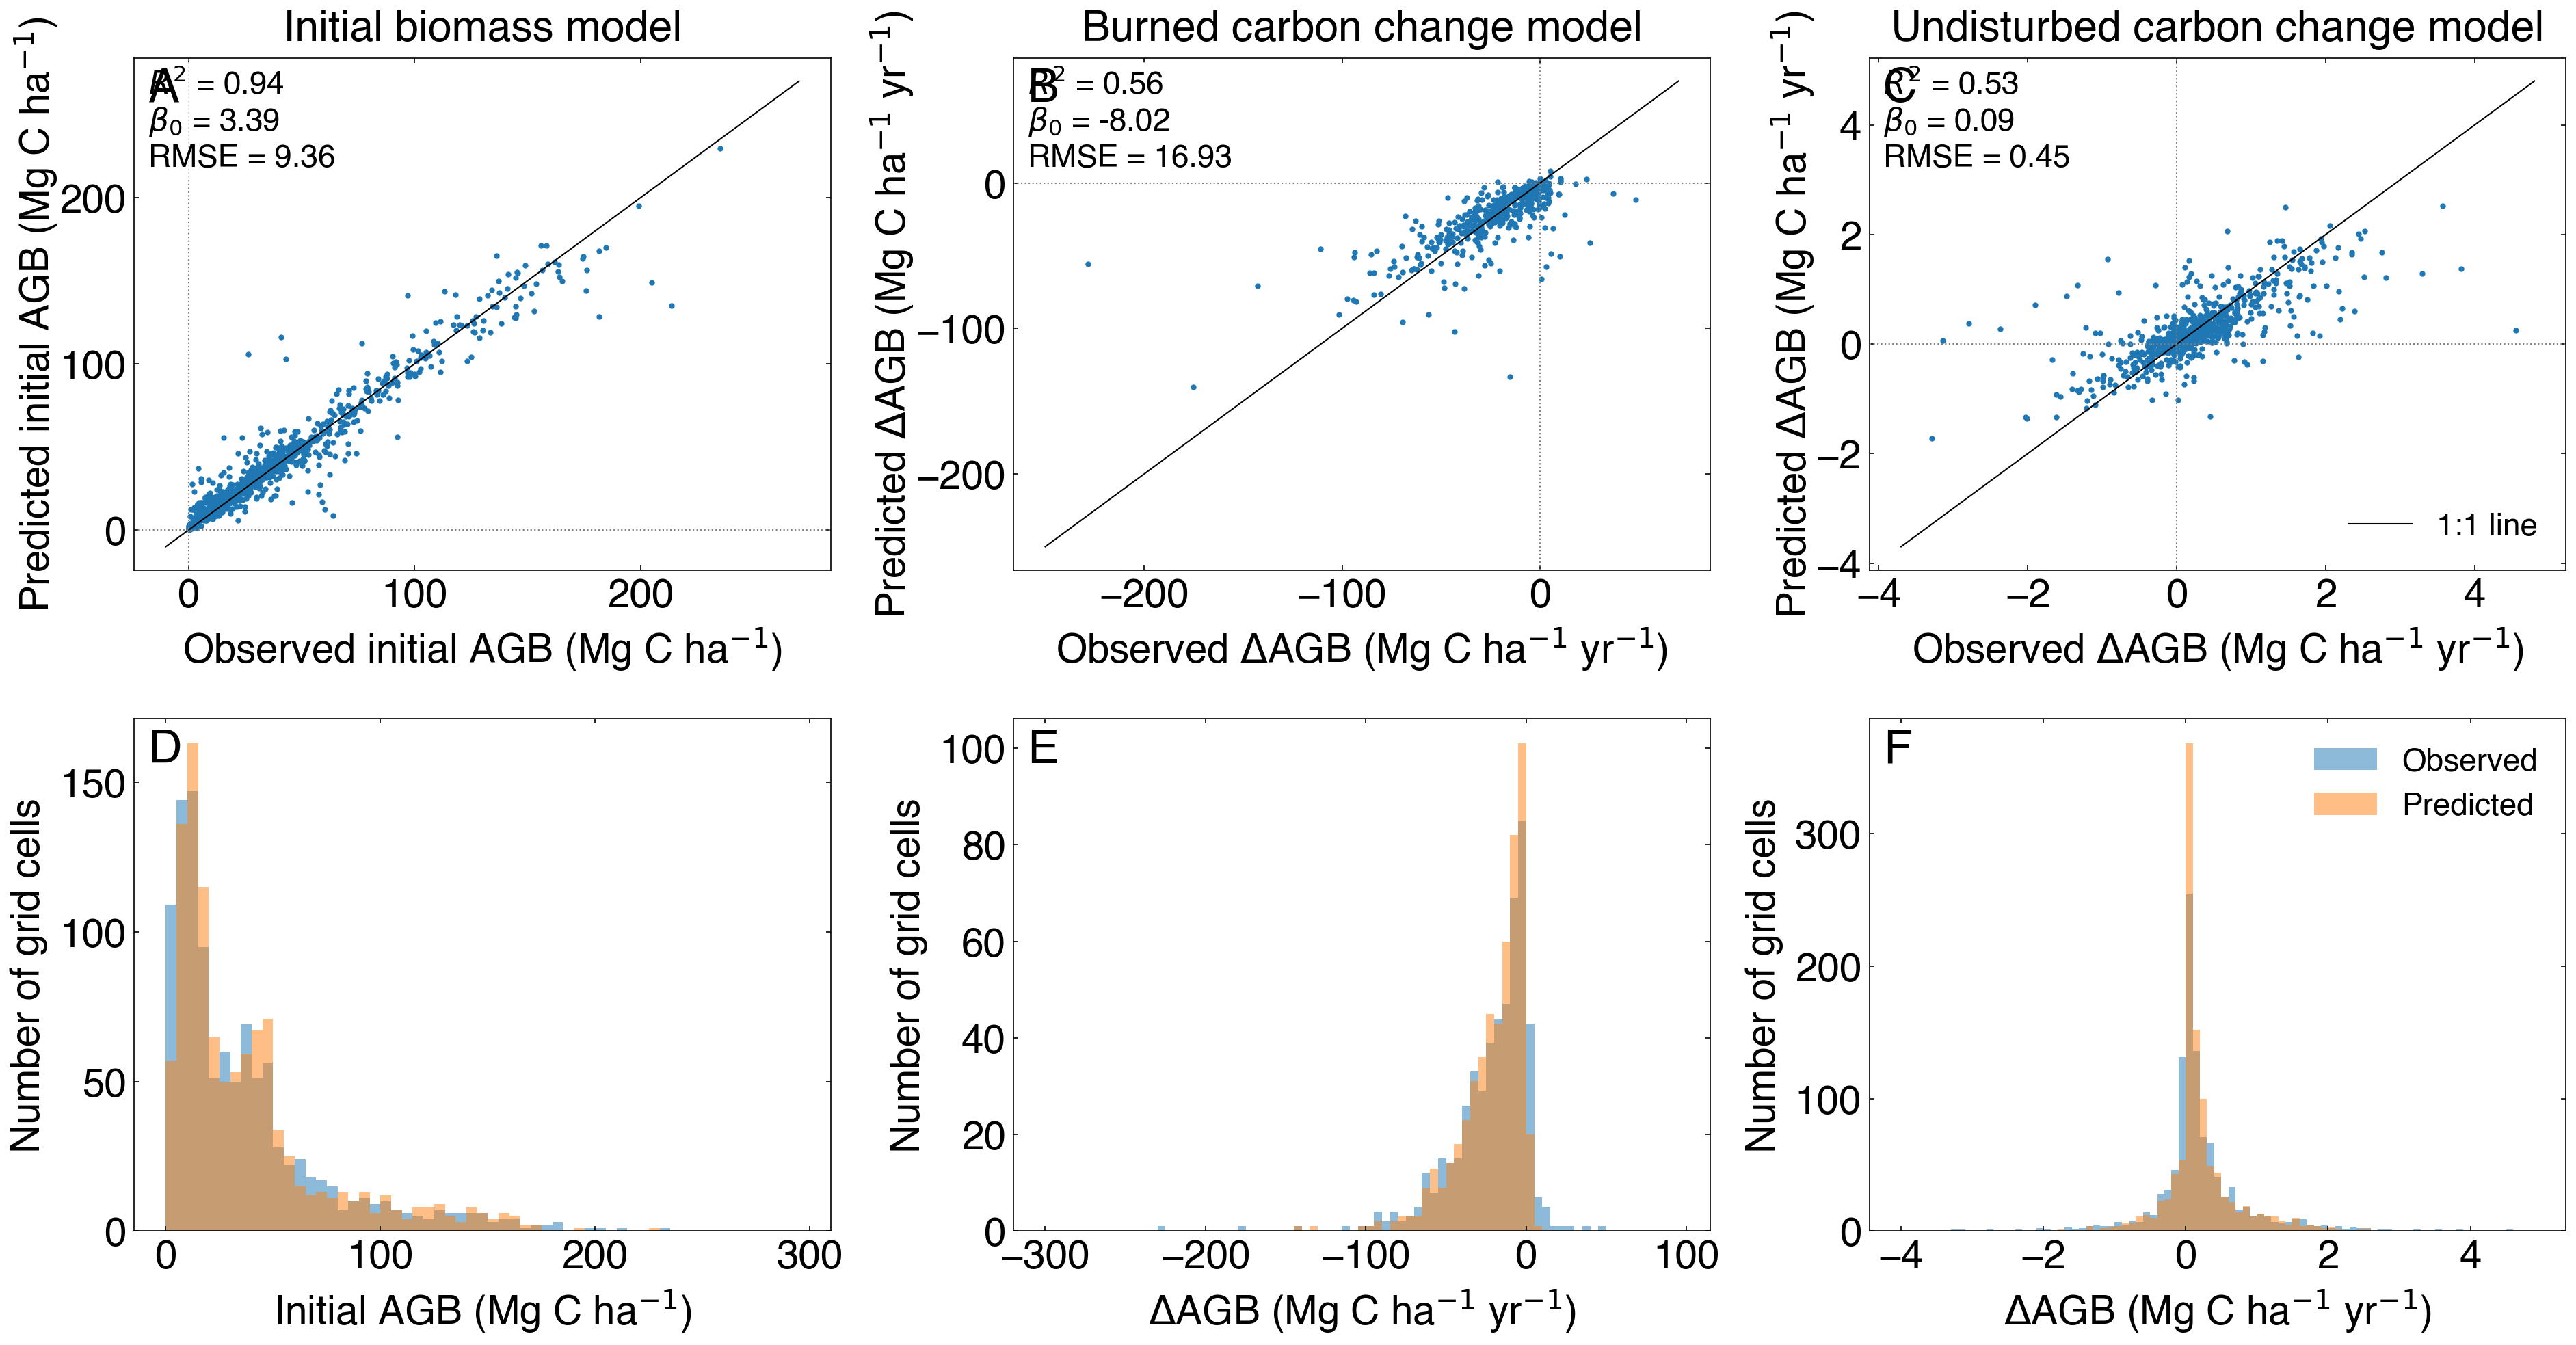

In [9]:
plt.rcParams.update({"font.size": 14})

fig, axes = plt.subplots(
    2,
    3,
    figsize=(25, 13),
    constrained_layout=True,
    gridspec_kw={"hspace": 0.07, "wspace": 0.03},
)

# --- Initial biomass ---
y_true = ds_binned_obs_init["biomass_init"].values.flatten()
y_pred = ds_binned_modeled_init["biomass_init"].values.flatten()
axes[0, 0].plot(y_true, y_pred, ".")
axes[0, 0].plot([-10, 270], [-10, 270], "-k", linewidth=1)
annotate_stats(axes[0, 0], y_true[~np.isnan(y_true)], y_pred[~np.isnan(y_true)])
axes[0, 0].set_xlabel(r"Observed initial AGB (Mg C ha$^{-1}$)", labelpad=7)
axes[0, 0].set_ylabel(r"Predicted initial AGB (Mg C ha$^{-1}$)", labelpad=0)
axes[0, 0].set_title("Initial biomass model", pad=12)

# --- Burned ---
xmin, xmax = -250, 70
y_true = ds_binned_obs_burned["biomass_delta"].values.flatten()
y_pred = ds_binned_modeled_burned["biomass_delta"].values.flatten()
axes[0, 1].plot(y_true, y_pred, ".")
axes[0, 1].plot([xmin, xmax], [xmin, xmax], "-k", linewidth=1)
annotate_stats(axes[0, 1], y_true[~np.isnan(y_true)], y_pred[~np.isnan(y_true)])
axes[0, 1].set_xlabel(r"Observed $\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)", labelpad=7)
axes[0, 1].set_ylabel(r"Predicted $\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)", labelpad=0)
axes[0, 1].set_title("Burned carbon change model", pad=12)

# --- Undisturbed ---
xmin, xmax = -3.7, 4.8
y_true = ds_binned_obs_undisturbed["biomass_delta"].values.flatten()
y_pred = ds_binned_modeled_undisturbed["biomass_delta"].values.flatten()
axes[0, 2].plot(y_true, y_pred, ".")
axes[0, 2].plot([xmin, xmax], [xmin, xmax], "-k", linewidth=1, label="1:1 line")
annotate_stats(axes[0, 2], y_true[~np.isnan(y_true)], y_pred[~np.isnan(y_true)])
axes[0, 2].set_xlabel(r"Observed $\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)", labelpad=7)
axes[0, 2].set_ylabel(r"Predicted $\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)", labelpad=0)
axes[0, 2].set_title("Undisturbed carbon change model", pad=12)
axes[0, 2].legend(loc="lower right")

for ax in axes[0, :]:
    ax.axhline(y=0, linestyle=":", color="gray", linewidth=1)
    ax.axvline(x=0, linestyle=":", color="gray", linewidth=1)

# --- Histograms ---
sns.histplot(
    ds_binned_obs_init["biomass_init"].values.flatten(),
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 0],
    bins=np.arange(0, 300, 5),
    label="Observed",
)
sns.histplot(
    ds_binned_modeled_init["biomass_init"].values.flatten(),
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 0],
    bins=np.arange(0, 300, 5),
    label="Predicted",
)
axes[1, 0].set_xlabel(r"Initial AGB (Mg C ha$^{-1}$)")

sns.histplot(
    ds_binned_obs_burned["biomass_delta"].values.flatten(),
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 1],
    bins=np.arange(-300, 100, 5),
    label="Observed",
)
sns.histplot(
    ds_binned_modeled_burned["biomass_delta"].values.flatten(),
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 1],
    bins=np.arange(-300, 100, 5),
    label="Predicted",
)
axes[1, 1].set_xlabel(r"$\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)")

sns.histplot(
    ds_binned_obs_undisturbed["biomass_delta"].values.flatten(),
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 2],
    bins=np.arange(-4, 5, 0.1),
    label="Observed",
)
sns.histplot(
    ds_binned_modeled_undisturbed["biomass_delta"].values.flatten(),
    edgecolor="none",
    alpha=0.5,
    ax=axes[1, 2],
    bins=np.arange(-4, 5, 0.1),
    label="Predicted",
)
axes[1, 2].set_xlabel(r"$\Delta$AGB (Mg C ha$^{-1}$ yr$^{-1}$)")
axes[1, 2].legend()

for ax in axes[1, :]:
    ax.set_ylabel("Number of grid cells")

# --- A-F labels ---
for ax, label in zip(axes.flatten(), "ABCDEF"):
    ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        fontsize=33,
        fontweight="bold",
        va="top",
        ha="left",
    )

plt.savefig(dir_info.dir_figures + "supp/Figure_S_grid_level_eval.pdf")
plt.show()